In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Logistic Regression is a supervised learning algorithm used for binary classification.
It predicts the probability of a customer churning (Exited = 1) using a sigmoid function.

Load preprocessed data

In [4]:
X_train = pd.read_csv('/content/drive/MyDrive/bank-churn-dataset/data/x_train.csv')
X_test  = pd.read_csv('/content/drive/MyDrive/bank-churn-dataset/data/x_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/bank-churn-dataset/data/y_train.csv').squeeze()
y_test  = pd.read_csv('/content/drive/MyDrive/bank-churn-dataset/data/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

X_train shape: (8000, 12)
X_test  shape: (2000, 12)
Churn rate in train: 20.4%
Churn rate in test:  20.3%


Train the model


In [5]:
lr_model = LogisticRegression(
    class_weight='balanced',   # handles class imbalance
    max_iter=1000,             # enough iterations to converge
    random_state=42,           # reproducible results
    solver='lbfgs'             # efficient solver for small-medium datasets
)

lr_model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


Make predictions

In [6]:
y_pred       = lr_model.predict(X_test)          # class labels  (0 or 1)
y_pred_proba = lr_model.predict_proba(X_test)[:,1]  # probability of churn

print(f"Total predictions: {len(y_pred)}")
print(f"Predicted churned:     {y_pred.sum()}")
print(f"Predicted not churned: {(y_pred == 0).sum()}")

Total predictions: 2000
Predicted churned:     736
Predicted not churned: 1264


 Evaluation metrics



  
For imbalanced data, accuracy alone is misleading.




A model that always predicts "not churned" would be 80% accurate
but completely useless.

F1 and ROC-AUC are more meaningful.

In [7]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 40)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)

# Full classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

   LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.7135  (71.35%)
  Precision : 0.3872
  Recall    : 0.7002
  F1 Score  : 0.4987
  ROC-AUC   : 0.7771

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



#  Confusion Matrix ──────────────────────────────────
Shows: True Positives, True Negatives, False Positives, False Negatives

TN = correctly predicted not churned

TP = correctly predicted churned   ← most important

FP = predicted churned but actually stayed (false alarm)

FN = predicted not churned but actually churned (missed churn) ← costly




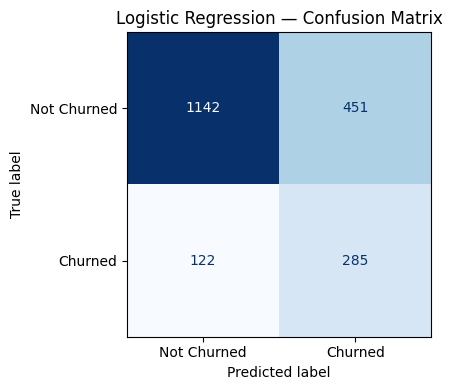

Saved to report/lr_confusion_matrix.png


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Churned', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bank-churn-dataset/report/lr_confusion_matrix.png', dpi=150)
plt.show()
print("Saved to report/lr_confusion_matrix.png")

----- ROC Curve ───

ROC curve shows the trade-off between True Positive Rate and

False Positive Rate at different classification thresholds.

AUC = Area Under Curve. Closer to 1.0 = better model.

A random classifier scores 0.5 (the diagonal line).

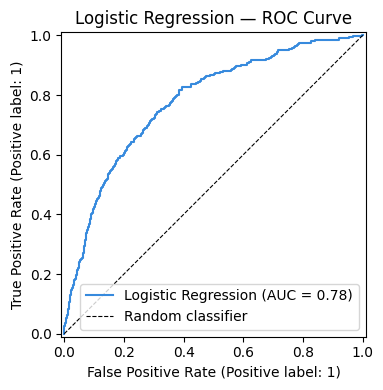

Saved to report/lr_roc_curve.png


In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name='Logistic Regression',
    ax=ax,
    color='#378ADD'
)
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random classifier')
ax.set_title('Logistic Regression — ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bank-churn-dataset/report/lr_roc_curve.png', dpi=150)
plt.show()
print("Saved to report/lr_roc_curve.png")

# Feature Coefficients

One of the biggest advantages of Logistic Regression —

we can see exactly which features push customers toward churning

Positive coefficient = increases churn probability

Negative coefficient = decreases churn probability


Feature Coefficients (impact on churn probability):
          Feature  Coefficient
              Age     0.801729
Geography_Germany     0.243623
          Balance     0.174670
  EstimatedSalary     0.050539
           Tenure    -0.018807
        HasCrCard    -0.031646
    NumOfProducts    -0.058073
      CreditScore    -0.087081
  Geography_Spain    -0.090637
 Geography_France    -0.132640
           Gender    -0.272106
   IsActiveMember    -0.442469


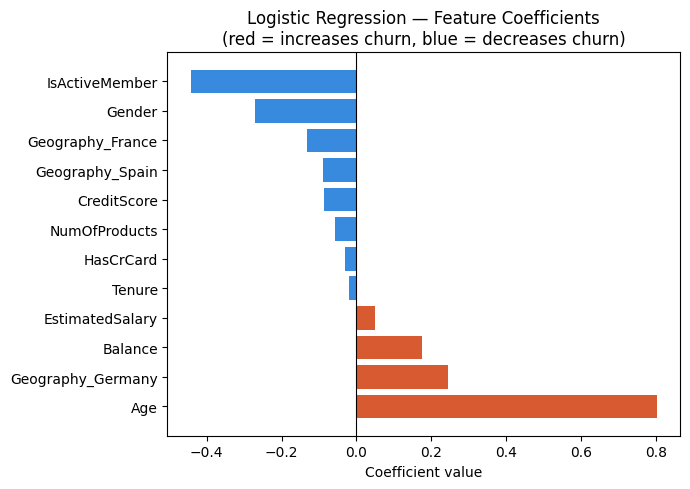

Saved to report/lr_feature_coefficients.png


In [10]:
feature_names = X_train.columns.tolist()
coefficients  = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients (impact on churn probability):")
print(coef_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#D85A30' if c > 0 else '#378ADD' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='none')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(red = increases churn, blue = decreases churn)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bank-churn-dataset/report/lr_feature_coefficients.png', dpi=150)
plt.show()
print("Saved to report/lr_feature_coefficients.png")


In [11]:
# Summary for report ───────────────────────────────
print("\n" + "=" * 40)
print("   SUMMARY — paste into report")
print("=" * 40)
print(f"  Algorithm     : Logistic Regression")
print(f"  Dataset       : Bank Customer Churn (10,000 rows)")
print(f"  Train/Test    : 80% / 20%")
print(f"  Class weight  : balanced")
print(f"  Solver        : lbfgs")
print(f"  Max iterations: 1000")
print()
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)


   SUMMARY — paste into report
  Algorithm     : Logistic Regression
  Dataset       : Bank Customer Churn (10,000 rows)
  Train/Test    : 80% / 20%
  Class weight  : balanced
  Solver        : lbfgs
  Max iterations: 1000

  Accuracy  : 71.35%
  Precision : 0.3872
  Recall    : 0.7002
  F1 Score  : 0.4987
  ROC-AUC   : 0.7771


In [15]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
pred = lr_model.predict(sample)[0]
prob = lr_model.predict_proba(sample)[0][1]

print(f"Actual Class: {actual}")
print(f"Predicted Class: {pred}")
print(f"Churn Probability: {prob:.2%}")

Actual Class: 0
Predicted Class: 0
Churn Probability: 31.75%


In [16]:
# Find a churned customer
churn_sample = X_test[y_test == 1].iloc[[0]]
actual = 1

pred = lr_model.predict(churn_sample)[0]
prob = lr_model.predict_proba(churn_sample)[0][1]

print(f"Actual Class: {actual}")
print(f"Predicted Class: {pred}")
print(f"Churn Probability: {prob:.2%}")

Actual Class: 1
Predicted Class: 1
Churn Probability: 81.51%
